# 07. Аналіз та візуалізація результатів

На цьому етапі виконується фінальний аналіз результатів
моделювання, отриманих у попередніх ноутбуках.

Нові моделі не навчаються.

Основні завдання:

- завантаження результатів моделювання;
- порівняння якості моделей;
- аналіз прогнозів найкращої моделі;
- аналіз помилок прогнозування;
- побудова фінальних візуалізацій;
- формування висновків за результатами експериментів.

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import sys
import importlib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [4]:
# ============================================================
# LOAD PROJECT
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/FitnessML_Master"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

importlib.invalidate_caches()

print("✓ Project connected")
print(PROJECT_DIR)

✓ Project connected
/content/drive/MyDrive/FitnessML_Master


In [5]:
# ============================================================
# IMPORT PROJECT MODULES
# ============================================================

import config
import utils

config = importlib.reload(config)
utils = importlib.reload(utils)

utils.section("Project modules")

print("✓ config.py loaded")
print("✓ utils.py loaded")


PROJECT MODULES
✓ config.py loaded
✓ utils.py loaded


In [6]:
# ============================================================
# LOAD MODEL RESULTS
# ============================================================

utils.section("Load model results")

model_results = pd.read_csv(
    config.TABLES_DIR / "06_model_results.csv"
)

nn_predictions = pd.read_csv(
    config.TABLES_DIR / "06_neural_network_predictions.csv"
)

display(model_results)


LOAD MODEL RESULTS


,Model,MAE,RMSE,R2
0,Linear Regression,239.690599,299.904654,-0.000097
1,Linear Regression + Engineered,239.702469,299.922320,-0.000215
2,Neural Network,239.978347,300.357974,-0.003123
3,Random Forest,242.008414,302.821678,-0.019646
4,Decision Tree,349.345620,437.865736,-1.131855


In [7]:
# ============================================================
# MODEL RMSE COMPARISON
# ============================================================

utils.section("Model RMSE comparison")

fig = plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

utils.save_figure(
    fig,
    "07_model_rmse_comparison.png"
)

plt.show()


MODEL RMSE COMPARISON
✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/07_model_rmse_comparison.png



ACTUAL VS PREDICTED


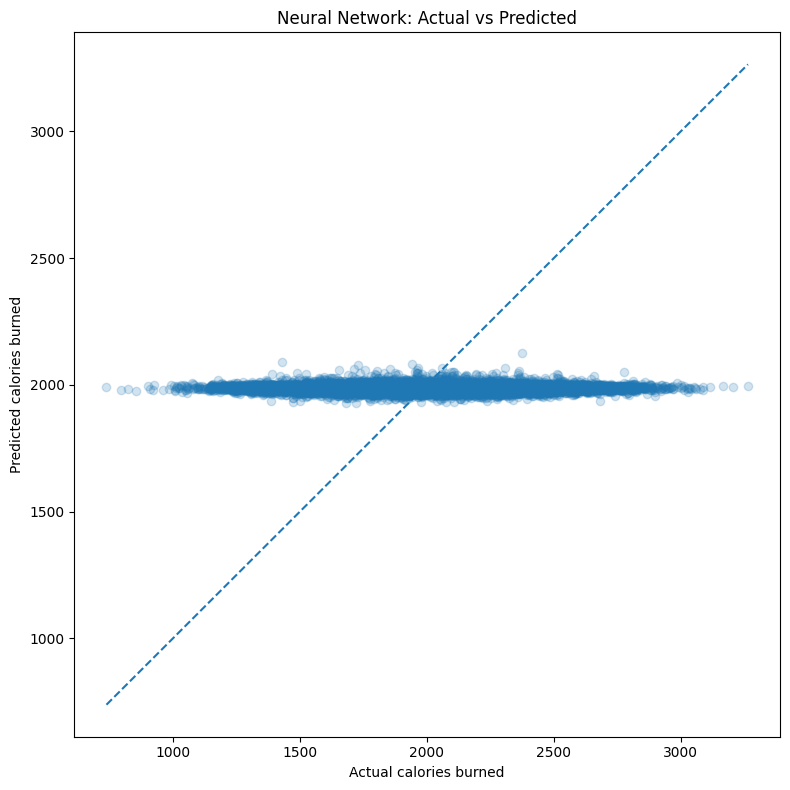

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/07_actual_vs_predicted.png


In [9]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

utils.section("Actual vs predicted")

fig = plt.figure(figsize=(8, 8))

plt.scatter(
    nn_predictions["actual"],
    nn_predictions["predicted"],
    alpha=0.2
)

min_value = min(
    nn_predictions["actual"].min(),
    nn_predictions["predicted"].min()
)

max_value = max(
    nn_predictions["actual"].max(),
    nn_predictions["predicted"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual calories burned")
plt.ylabel("Predicted calories burned")
plt.title("Neural Network: Actual vs Predicted")

plt.tight_layout()
plt.show()

utils.save_figure(
    fig,
    "07_actual_vs_predicted.png"
)


In [10]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

utils.section("Residual analysis")

nn_predictions["residual"] = (
    nn_predictions["actual"]
    - nn_predictions["predicted"]
)

display(
    nn_predictions["residual"].describe()
)


RESIDUAL ANALYSIS


,residual
count,36500.000000
mean,14.267905
std,300.023008
min,-1254.819501
25%,-188.619640
50%,13.023497
75%,216.367698
max,1270.233482


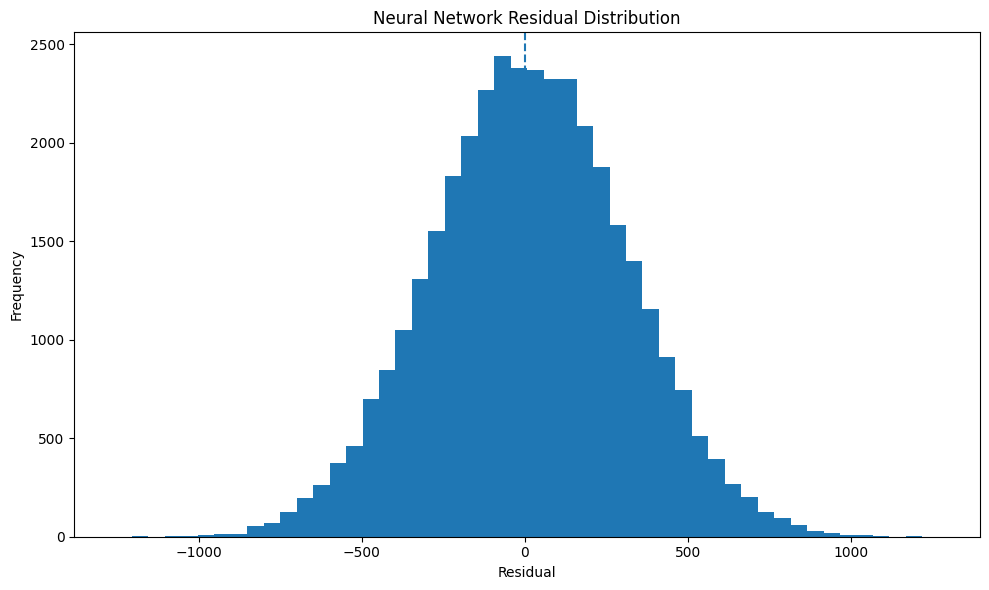

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/07_residual_distribution.png


In [12]:
# ============================================================
# RESIDUAL DISTRIBUTION
# ============================================================

fig = plt.figure(figsize=(10, 6))

plt.hist(
    nn_predictions["residual"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Neural Network Residual Distribution")

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "07_residual_distribution.png"
)



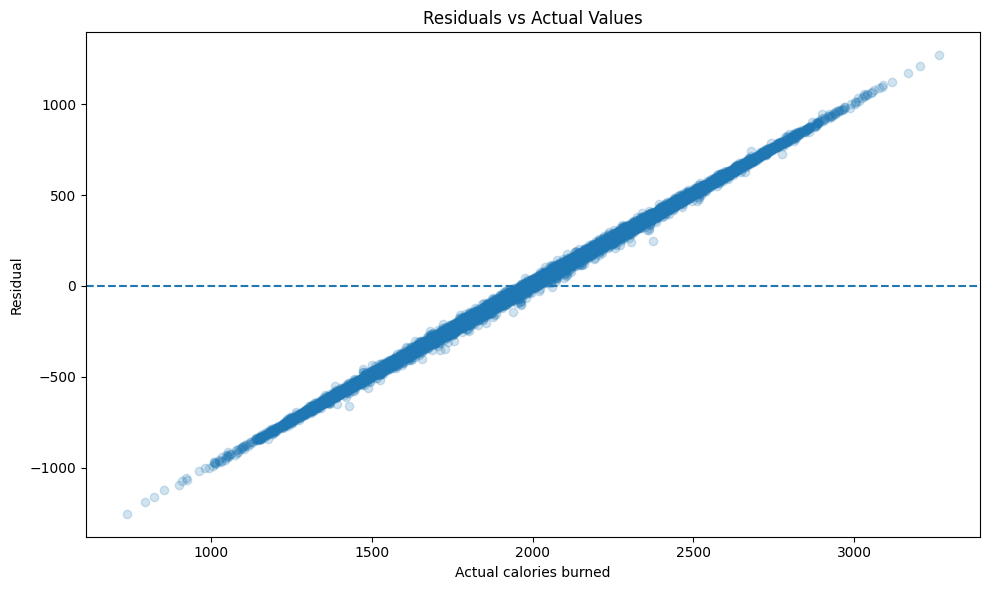

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/07_residuals_vs_actual.png


In [14]:
# ============================================================
# RESIDUALS VS ACTUAL
# ============================================================

fig = plt.figure(figsize=(10, 6))

plt.scatter(
    nn_predictions["actual"],
    nn_predictions["residual"],
    alpha=0.2
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual calories burned")
plt.ylabel("Residual")
plt.title("Residuals vs Actual Values")

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "07_residuals_vs_actual.png"
)




FINAL MODEL METRICS


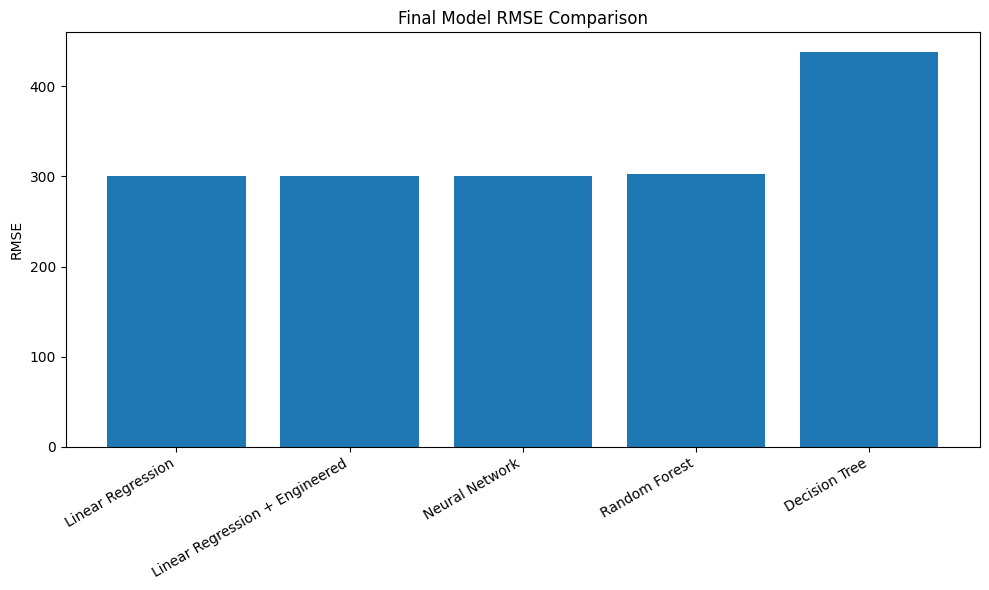

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/07_final_model_rmse.png


In [15]:
# ============================================================
# FINAL MODEL METRICS
# ============================================================

utils.section("Final model metrics")

fig = plt.figure(figsize=(10, 6))

x = np.arange(len(model_results))

plt.bar(
    x,
    model_results["RMSE"]
)

plt.xticks(
    x,
    model_results["Model"],
    rotation=30,
    ha="right"
)

plt.ylabel("RMSE")
plt.title("Final Model RMSE Comparison")

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "07_final_model_rmse.png"
)


In [16]:
# ============================================================
# FINAL FINDINGS
# ============================================================

utils.section("Final findings")

best_model = model_results.loc[
    model_results["RMSE"].idxmin()
]

print(
    f"Best model by RMSE: {best_model['Model']}"
)

print(
    f"MAE:  {best_model['MAE']:.4f}"
)

print(
    f"RMSE: {best_model['RMSE']:.4f}"
)

print(
    f"R²:   {best_model['R2']:.6f}"
)

print("\nKey findings:")
print(
    "- Linear Regression achieved the lowest RMSE "
    "among the evaluated models."
)

print(
    "- Feature engineering did not provide a meaningful "
    "improvement over the baseline model."
)

print(
    "- The Neural Network did not outperform the classical "
    "regression models."
)

print(
    "- The evaluated models demonstrated limited "
    "predictive performance for the target variable."
)


FINAL FINDINGS
Best model by RMSE: Linear Regression
MAE:  239.6906
RMSE: 299.9047
R²:   -0.000097

Key findings:
- Linear Regression achieved the lowest RMSE among the evaluated models.
- Feature engineering did not provide a meaningful improvement over the baseline model.
- The Neural Network did not outperform the classical regression models.
- The evaluated models demonstrated limited predictive performance for the target variable.


In [17]:
# ============================================================
# NOTEBOOK COMPLETED
# ============================================================

utils.section("Analysis and visualization completed")


ANALYSIS AND VISUALIZATION COMPLETED
